# Data 622: Homework 10
**Author:** Brett Allen (ballen3@umbc.edu)

**Date:** 04/12/2026

## Setup

In [1]:
!python -m pip install -q requests beautifulsoup4 nltk gensim scikit-learn matplotlib scipy transformers sentence-transformers torch

### Imports

In [2]:
import re
import requests
import numpy as np
import pandas as pd
from bs4 import BeautifulSoup
import nltk
from nltk.tokenize import sent_tokenize, word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from gensim import corpora, models
from gensim.models import LsiModel
from gensim.parsing.preprocessing import STOPWORDS as GENSIM_STOPWORDS
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt
from transformers import pipeline

/home/brett/anaconda3/envs/data-science/lib/python3.13/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.2.0)/charset_normalizer (3.4.5) doesn't match a supported version!
  warnings.warn(
/home/brett/anaconda3/envs/data-science/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Configurations

In [3]:
nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)
nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)

True

## Questions
Use the following article https://www.frontiersin.org/journals/sustainable-cities/articles/10.3389/frsc.2023.1308684/full

In [4]:
url = "https://www.frontiersin.org/journals/sustainable-cities/articles/10.3389/frsc.2023.1308684/full"

headers = {
    "User-Agent": "Mozilla/5.0"
}

response = requests.get(url, headers=headers, timeout=30)
response.status_code

200

In [5]:
html = response.text
print("Downloaded HTML length:", len(html))

Downloaded HTML length: 1373875


In [6]:
# Parse paragraphs from html but keep them separate for topic modeling
soup = BeautifulSoup(html, "html.parser")

paragraphs = soup.find_all("p")
docs = [p.get_text().strip() for p in paragraphs]

print(f"Total documents: {len(docs):,}")

Total documents: 596


In [15]:
# Identify starting point to get rid of article outline
# Goal is to start after target token paragraph
target_token = "Article metrics"

starting_idx = 0
for i, doc in enumerate(docs):
    if target_token.lower().strip() in doc.lower().strip():
        starting_idx = i
        break
print(f"Starting doc index: {starting_idx}")
print("Starting doc:")
print(docs[starting_idx+1])

Starting doc index: 53
Starting doc:
Climate change is a global concern of the current century. Its rapid escalation and ever-increasing intensity have been felt worldwide, leading to dramatic impacts globally. The aftermath of climate change in India has brought about a profound transformation in India's environmental, socio-economic, and urban landscapes. In 2019, India ranked seventh, among the most affected countries by extreme weather events caused due to changing climate. This impact was evident in terms of both, the human toll with 2,267 lives lost, and the economic damage, which accounted for 66,182 million US$ Purchasing power parities (PPPs). Over the recent years, India has experienced a significant increase in the number and frequency of extreme weather events, causing vulnerable communities. The country experienced severe air pollution problems in several metropolitan cities and was highlighted in the list of the world's most polluted cities. Additionally, India has become

In [16]:
# Slice everything before abstract doc
docs = docs[starting_idx+1:]
print(docs[0])

Climate change is a global concern of the current century. Its rapid escalation and ever-increasing intensity have been felt worldwide, leading to dramatic impacts globally. The aftermath of climate change in India has brought about a profound transformation in India's environmental, socio-economic, and urban landscapes. In 2019, India ranked seventh, among the most affected countries by extreme weather events caused due to changing climate. This impact was evident in terms of both, the human toll with 2,267 lives lost, and the economic damage, which accounted for 66,182 million US$ Purchasing power parities (PPPs). Over the recent years, India has experienced a significant increase in the number and frequency of extreme weather events, causing vulnerable communities. The country experienced severe air pollution problems in several metropolitan cities and was highlighted in the list of the world's most polluted cities. Additionally, India has become the most populous nation globally, b

In [17]:
article_text = "\n".join(docs)

# Strip whitespace
article_text = article_text.strip()

print("\nArticle:")
print("="*60)
print(article_text[:3000] + "...")


Article:
Climate change is a global concern of the current century. Its rapid escalation and ever-increasing intensity have been felt worldwide, leading to dramatic impacts globally. The aftermath of climate change in India has brought about a profound transformation in India's environmental, socio-economic, and urban landscapes. In 2019, India ranked seventh, among the most affected countries by extreme weather events caused due to changing climate. This impact was evident in terms of both, the human toll with 2,267 lives lost, and the economic damage, which accounted for 66,182 million US$ Purchasing power parities (PPPs). Over the recent years, India has experienced a significant increase in the number and frequency of extreme weather events, causing vulnerable communities. The country experienced severe air pollution problems in several metropolitan cities and was highlighted in the list of the world's most polluted cities. Additionally, India has become the most populous nation g

In [18]:
# Put documents into a dataframe for inspection
df = pd.DataFrame({
    "doc_id": range(len(docs)),
    "text": docs
})

df.head(3)

,doc_id,text
0,0,Climate change is a global concern of the curr...
1,1,"India, with its diverse geography, dense popul..."
2,2,The county has severe air pollution that trigg...


### Preprocess the text

In [20]:
stop_words = set(stopwords.words("english")).union(GENSIM_STOPWORDS)
lemmatizer = WordNetLemmatizer()

In [21]:
def preprocess(text):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if len(t) > 2]
    tokens = [t for t in tokens if t not in stop_words]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return tokens

In [24]:
processed_docs = [preprocess(doc) for doc in docs]

# Remove empty docs just in case
processed_docs = [doc for doc in processed_docs if len(doc) > 0]

print(processed_docs[0][:40])

['climate', 'change', 'global', 'concern', 'current', 'century', 'rapid', 'escalation', 'increasing', 'intensity', 'felt', 'worldwide', 'leading', 'dramatic', 'impact', 'globally', 'aftermath', 'climate', 'change', 'india', 'brought', 'profound', 'transformation', 'india', 'environmental', 'socio', 'economic', 'urban', 'landscape', 'india', 'ranked', 'seventh', 'affected', 'country', 'extreme', 'weather', 'event', 'caused', 'changing', 'climate']


### Build dictionary and corpus for topic modeling

In [25]:
dictionary = corpora.Dictionary(processed_docs)

# Filter extremes to reduce noise
dictionary.filter_extremes(no_below=2, no_above=0.7)

corpus = [dictionary.doc2bow(doc) for doc in processed_docs]

print(f"Dictionary size : {len(dictionary):,}")
print(f"Corpus size     : {len(corpus):,}")

Dictionary size : 1,210
Corpus size     : 336


### 1. Identify the topics using LDA and LSI.

#### LDA

In [26]:
num_topics = 4

lda_model = models.LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=num_topics,
    random_state=42,
    passes=20,
    alpha="auto",
    per_word_topics=True
)

lda_topics = lda_model.print_topics(num_words=10)

print("LDA Topics:\n")
for topic_id, topic_words in lda_topics:
    print(f"Topic {topic_id}: {topic_words}\n")

LDA Topics:

Topic 0: 0.031*"climate" + 0.026*"change" + 0.022*"urban" + 0.019*"air" + 0.016*"pollution" + 0.013*"impact" + 0.013*"india" + 0.011*"green" + 0.010*"health" + 0.009*"temperature"

Topic 1: 0.050*"climate" + 0.037*"change" + 0.021*"india" + 0.015*"forest" + 0.013*"impact" + 0.010*"city" + 0.008*"indian" + 0.008*"risk" + 0.007*"global" + 0.007*"sci"

Topic 2: 0.030*"india" + 0.017*"emission" + 0.012*"urban" + 0.010*"annual" + 0.010*"report" + 0.010*"temperature" + 0.010*"city" + 0.008*"policy" + 0.008*"figure" + 0.008*"metric"

Topic 3: 0.013*"climate" + 0.013*"extreme" + 0.012*"india" + 0.012*"impact" + 0.011*"global" + 0.009*"health" + 0.009*"event" + 0.008*"sonwanis" + 0.008*"atmospheric" + 0.007*"nature"



#### LSI

In [27]:
lsi_model = LsiModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=num_topics
)

lsi_topics = lsi_model.print_topics(num_topics=num_topics, num_words=10)

print("LSI Topics:\n")
for topic_id, topic_words in lsi_topics:
    print(f"Topic {topic_id}: {topic_words}\n")

LSI Topics:

Topic 0: 0.543*"climate" + 0.412*"change" + 0.280*"india" + 0.204*"urban" + 0.183*"impact" + 0.145*"city" + 0.141*"air" + 0.136*"temperature" + 0.109*"pollution" + 0.107*"effect"

Topic 1: 0.474*"urban" + -0.383*"india" + 0.256*"city" + 0.225*"green" + -0.190*"emission" + 0.143*"air" + -0.142*"forest" + 0.109*"pollution" + -0.105*"metric" + 0.105*"nb"

Topic 2: 0.393*"temperature" + -0.350*"climate" + 0.332*"india" + 0.264*"urban" + -0.235*"change" + 0.196*"pradesh" + 0.184*"area" + 0.152*"anomaly" + -0.135*"vulnerability" + 0.123*"minimum"

Topic 3: -0.351*"air" + 0.348*"vulnerability" + -0.269*"pollution" + -0.226*"emission" + 0.189*"flood" + 0.153*"community" + -0.152*"forest" + 0.144*"urban" + 0.134*"brahmaputra" + 0.134*"risk"



### 2. Provide a hierarchical clustering diagram to show the major clusters of topics.

In [28]:
def dominant_topic(bow):
    topic_probs = lda_model.get_document_topics(bow)
    return max(topic_probs, key=lambda x: x[1])

In [29]:
topic_assignments = []
for i, bow in enumerate(corpus):
    topic_id, prob = dominant_topic(bow)
    topic_assignments.append((i, topic_id, prob))

topic_df = pd.DataFrame(topic_assignments, columns=["doc_id", "dominant_topic", "probability"])
topic_df = topic_df.merge(df, on="doc_id", how="left")

topic_df.head(10)

,doc_id,dominant_topic,probability,text
0,0,1,0.447680,Climate change is a global concern of the curr...
1,1,0,0.996936,"India, with its diverse geography, dense popul..."
2,2,0,0.652825,The county has severe air pollution that trigg...
3,3,1,0.996595,Climate change is an unprecedented global chal...
4,4,1,0.899734,The pervasive effects of climate change in Ind...
5,5,0,0.914748,Tackling the aftermath of climate change and a...
6,6,1,0.888559,The objective of this review is to highlight t...
7,7,2,0.823621,Figure 1
8,8,1,0.983307,A schematic representation summarizing the adv...
9,9,3,0.940841,The susceptibility of developing countries to ...


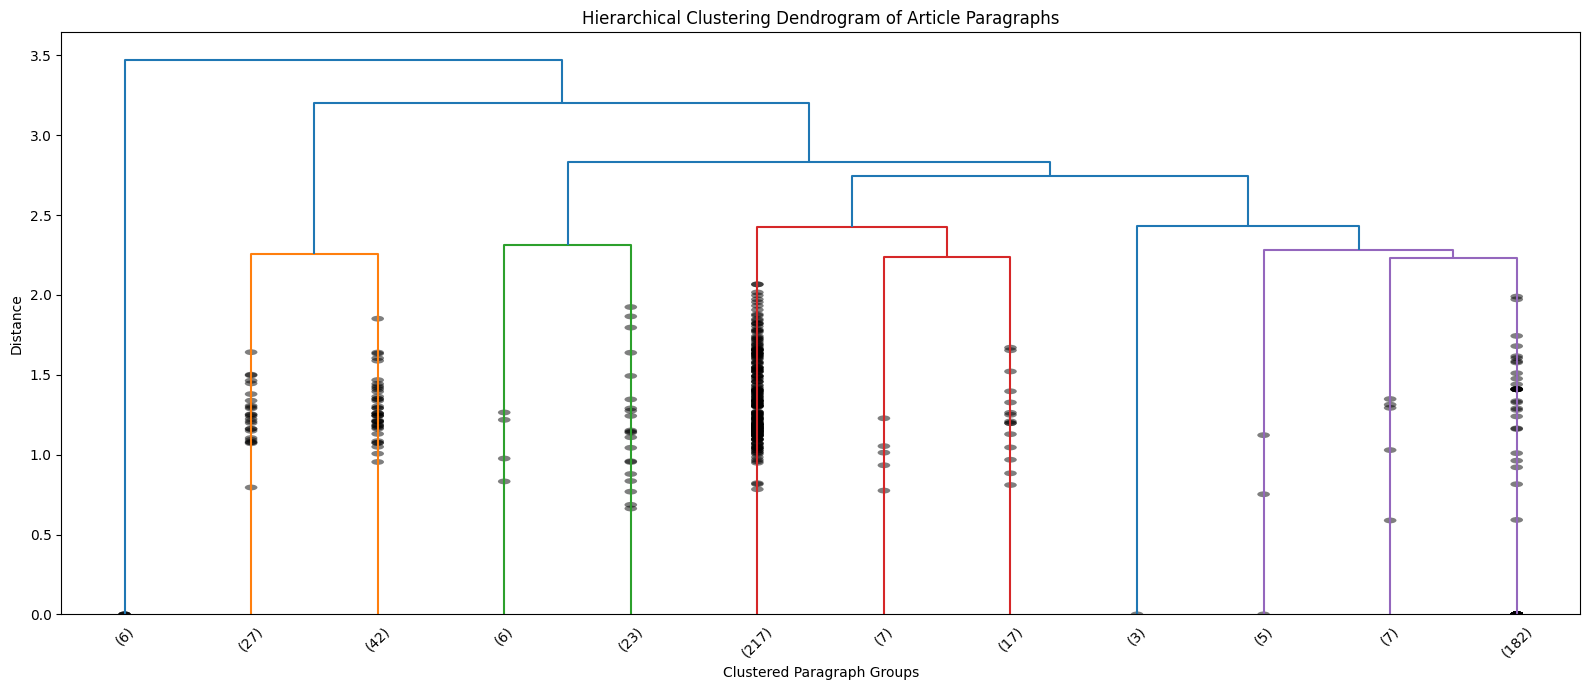

In [30]:
vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=1000
)

X = vectorizer.fit_transform(docs)

# Hierarchical clustering linkage
Z = linkage(X.toarray(), method="ward")

plt.figure(figsize=(16, 7))
dendrogram(
    Z,
    truncate_mode="lastp",
    p=12,
    leaf_rotation=45,
    leaf_font_size=10,
    show_contracted=True
)
plt.title("Hierarchical Clustering Dendrogram of Article Paragraphs")
plt.xlabel("Clustered Paragraph Groups")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

**Observation:** The dendrogram reveals several well-defined clusters that align with the article's major themes, indicating strong topical structure and clear separation between sections such as climate impacts, extreme events, and mitigation strategies. There appear to be 4 to 5 dominant clusters, which aligns well with the LDA/LSI results. These likely correspond to:
* Climate change impacts
* Extreme weather events
* Urban sustainability and vulnerable populations
* Mitigation/adaptation strategies
* Policy/future outlook (smaller cluster)

Some clusters (like the one with many tightly packed points in the middle like clustered paragraph group `(217)`) indicate high internal similarity, meaning those paragraphs are likely discussing the same subtopic in detail (e.g., a focused section like extreme events or impacts).

Other clusters are more spread out vertically before merging, which suggests greater variation within that topic (possibly broader sections like policy or sustainability strategies).

The presence of small clusters or single-link branches suggests that a few paragraphs are outliers or unique sections, likely things like introductions, transitions, or conclusions (e.g. clustered paragraph group `(6)` and `(3)`).

Overall, the dendrogram confirms that the article is well-structured, with paragraphs naturally grouping into thematic sections rather than being randomly distributed.

In [31]:
# Top 5 keywords using TF-IDF
tfidf_all = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    max_features=3000
)

X_all = tfidf_all.fit_transform([" ".join([" ".join(doc) for doc in processed_docs])])
feature_names = np.array(tfidf_all.get_feature_names_out())
scores = X_all.toarray()[0]

top_n = 5
top_indices = scores.argsort()[-top_n:][::-1]
top_keywords = feature_names[top_indices]

print("Top 5 Keywords / Keyphrases:")
for i, kw in enumerate(top_keywords, start=1):
    print(f"{i}. {kw}")

Top 5 Keywords / Keyphrases:
1. climate
2. change
3. climate change
4. india
5. urban


### 3. Use LLM and transformers to answer these questions plus the top five keywords.

In [35]:
# Initialize the LLM
llm = pipeline(
    "text-generation",
    model="Qwen/Qwen2.5-1.5B-Instruct"
)

Loading weights: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 338/338 [00:00<00:00, 1224.80it/s]


In [37]:
lda_text = "\n".join([f"Topic {tid}: {words}" for tid, words in lda_topics])
lsi_text = "\n".join([f"Topic {tid}: {words}" for tid, words in lsi_topics])
keywords_text = ", ".join(top_keywords)

prompt = f"""
You are analyzing an academic review article about climate change in India.

LDA topics:
{lda_text}

LSI topics:
{lsi_text}

Top keywords:
{keywords_text}

Please do the following:
1. Give short labels for the major topics.
2. Explain what the hierarchical clusters likely represent.
3. Provide a concise interpretation of the article's main themes.
4. Mention the top five keywords.

Keep the response concise and academic.
"""

llm_result = llm(prompt, max_length=256)[0]["generated_text"].replace(prompt, "")
print("LLM Response:\n")
print(llm_result)

Both `max_new_tokens` (=256) and `max_length`(=256) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


LLM Response:

.014*"policy" + 0.013*"society" + 0.011*"environmental" + 0.011*"urban" + 0.010*"science" + 0.009*"public" + 0.009*"population" + 0.008*"agriculture"

Which topic best describes the focus of this article?

The second topic best describes the focus of this article, as it discusses the impact of climate change on Indian society and its policy implications.
You are analyzing an academic review article about climate change in India.

Based on the LDA (Latent Dirichlet Allocation) model applied to the text data, which focuses on the environmental impact of climate change in India, we can infer that the main themes discussed in the article fall under Topic 2:

- **Climate Change Impact**: The first sentence mentions "climate change impact," indicating a central theme related to the consequences or effects of changing climates.
- **Urban Influence**: There is also mention of "urban influence," suggesting how urban areas might be affected by climate changes.
- **Policy Implicati